In [1]:
import os
import torch, torchvision
from torch import nn
from torchvision import datasets, transforms
from torchvision.models import swin_b
from torch.utils.data import DataLoader
import timm

from collections import Counter
import gc
from time import sleep
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from IPython.display import display


#Utilities shared between models
import helpers as h

gc.collect()
torch.cuda.empty_cache()

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device


# SwinTransformer-Base

## Config

In [ ]:
#Config

modelName = "SwinTransformer-Base"
modelPath = f"Models/{modelName}.pth"
historyPath = f"Models/{modelName}_history.csv" #recorded stats during training
statePath = f"Models/{modelName}_state.pth"  #optimizer & current epoch

purge = False   #Start a new model from scratch
training = True  #Whether to train the model or just load it

#Paralell training examples 
BATCH_SIZE = 4   #GPU a limit
#CPU workers to load data to gpu
WORKERS = 4   #Ezt még talán lehet növelni

LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4

## Loading / initializing resources

### DataLoader and dataset parameters

In [3]:
train_loader = h.GetTrainingDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
val_loader = h.GetValDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
test_loader = h.GetTestDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)

ClassNames = train_loader.dataset.classes
numClasses = len(ClassNames)

print(f"Classes: {ClassNames}")
print(f"Number of classes: {numClasses}")

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 8


In [4]:
#Deriving Inverse frequency of classes to balance rare classes
totalSamples = len(train_loader.dataset) + len(test_loader.dataset) + len(val_loader.dataset)

samplesPerClass = Counter(train_loader.dataset.targets) 
samplesPerClass.update(Counter(test_loader.dataset.targets))
samplesPerClass.update(Counter(val_loader.dataset.targets))

inverseFrequencies = [ totalSamples/(numClasses * samplesPerClass[i]) for i in range(numClasses) ]
#freqvInv = [3.652, 0.953, 1.207, 13.248, 0.246, 0.700, 5.042, 12.515]  #from excel

print(totalSamples)
print(inverseFrequencies)

25331
[3.652104959630911, 0.9528663857959675, 1.2066977896341464, 13.248430962343097, 0.24593203883495146, 0.7002156125608138, 5.041998407643312, 12.515316205533598]


### Model

In [5]:
#Model definition
model = timm.create_model(
    "swin_tiny_patch4_window7_224",   # <- first parameter
    pretrained=True,    #On imageNet
    num_classes=numClasses
)

### Loss function and optimizer

In [6]:
#LossFN and Optimizer
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(inverseFrequencies))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### Loading if available

In [7]:
#Loading or initializing model and statistics

epochs_done = 0
history = None

if not purge and os.path.exists(modelPath):
    model.load_state_dict(torch.load(modelPath))    #this loads latest model, not bestVal
    state = torch.load(statePath)
    optimizer.load_state_dict(state["optimizer"])
    epochs_done = state["epoch"]
    #load recorded stats too
    history = pd.read_csv(historyPath)
    print("Loaded last state")


## Training

In [8]:
model = model.to(device)
criterion = criterion.to(device)

In [20]:
#Training config (=epoch overwrites)
#0 = off, priority: stopAt > maxOW
stopAt = 17
maxEpochOW = 0

#stopAt = 10    #stop at specific epoch
epochs = h.MAX_EPOCHS
if maxEpochOW: epochs = maxEpochOW
if stopAt: epochs = stopAt

if training:
    bestTrainAcc = 0.0
    bestValAcc = 0.0
    if history is not None and len(history) > 0:
        bestTrainAcc = history["train_acc"].max()
        bestValAcc = history["val_acc"].max()

    
    for epoch in range(epochs_done, epochs):
        print(f"Epoch {epoch+1}/{epochs} \t| ", end="")
        #Executing training and validation
        #train_loss, train_acc = 0,0
        train_loss, train_acc = h.trainingEpoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, CM = h.validate(model, val_loader, criterion, device)

        print(
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
        )
        epochs_done += 1

        #Recording statistics
        sampleRow = {
            "epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc
        }
        sampleRow.update(h.FlattenCM(CM))
        if history is None:
            history = pd.DataFrame(columns=sampleRow.keys())
        history.loc[len(history)] = sampleRow

        #Saving snapshot
        torch.save(model.state_dict(), modelPath)
        torch.save({
                "epoch": epoch+1,
                "optimizer": optimizer.state_dict()
            }, statePath)        
        history.to_csv(historyPath, index=False)

        #saving best model
        if val_acc > bestValAcc:
            bestValAcc = val_acc
            torch.save(model.state_dict(), f"Models/{modelName}_bestVal.pth")
        
        if epoch == epochs-1: break
        sleep(90) #Let GPU cool a little

else:
    print("Already trained")

display(history)

Epoch 16/17 	| train loss: 0.1812, train acc: 0.9288 | val loss: 0.6094, val acc: 0.8209
Epoch 17/17 	| train loss: 0.1749, train acc: 0.9318 | val loss: 0.5200, val acc: 0.8391


,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,...,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.097227,0.665581,0.730634,0.732305,65,30,37,1,8,...,19,0,0,1,0,0,8,2,0,22
1,2,0.844130,0.732307,0.642694,0.774614,38,7,8,0,2,...,27,0,0,0,0,0,2,0,0,22
2,3,0.700540,0.771740,0.596872,0.793594,63,22,22,0,4,...,31,0,0,3,2,1,2,1,1,25
3,4,0.600811,0.801945,0.566637,0.792803,47,7,18,0,3,...,39,0,0,1,2,0,3,2,0,25
4,5,0.517079,0.823956,0.542293,0.810202,54,10,11,0,5,...,37,0,0,2,0,0,1,0,0,25
5,6,0.453637,0.840342,0.565397,0.797153,58,27,19,1,8,...,40,0,0,2,0,0,12,2,0,24
6,7,0.392681,0.859392,0.706397,0.778964,56,6,16,1,7,...,37,0,0,5,0,0,10,1,0,25
7,8,0.355565,0.866499,0.460602,0.841835,60,10,13,0,6,...,39,0,0,0,0,0,3,0,0,23
8,9,0.308826,0.881749,0.469006,0.839858,66,3,14,2,7,...,42,0,0,0,0,0,0,0,0,24
9,10,0.281113,0.894532,0.500617,0.830763,55,3,12,1,5,...,43,0,0,1,0,0,1,0,0,24


In [21]:
#latest CM
CM = h.ParseCM(history.iloc[-1][5:])
#display(history)
display(CM)

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,70,17,8,2,8,10,6,0
Basal cell carcinoma,5,280,6,0,11,7,4,0
Benign keratosis-like lesions,7,4,202,0,43,26,8,0
Dermatofibroma,1,0,0,20,1,0,2,0
Melanocytic nevi,2,22,26,1,1147,66,1,0
Melanoma,0,4,15,0,74,338,1,0
Squamous cell carcinoma,1,3,4,0,2,5,40,0
Vascular lesions,0,2,1,0,1,0,0,25


## Progress trough training

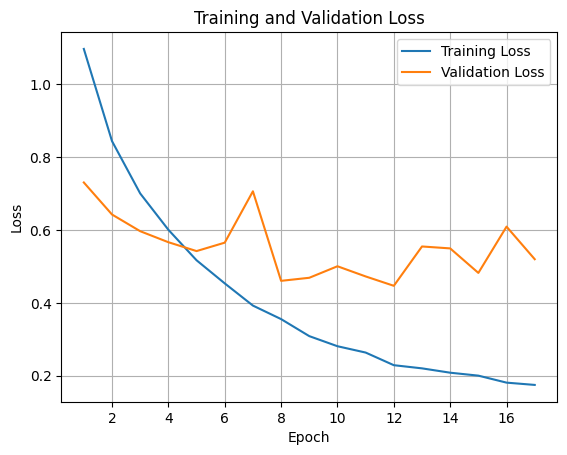

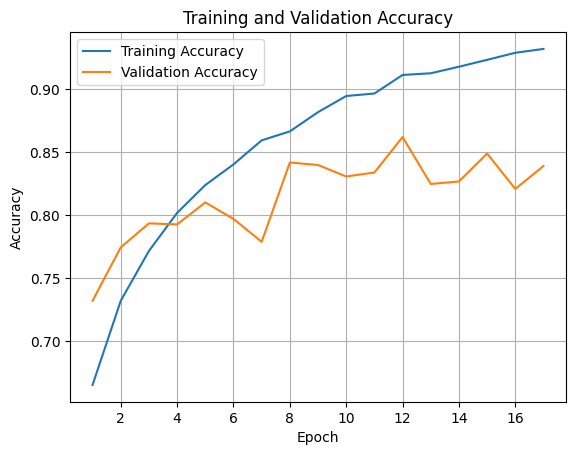

In [22]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

## Trying out trained model

In [26]:
#Testing should be done on best performing model

mpath = f"Models/{modelName}.pth" #latest model
mpath = f"Models/{modelName}_bestVal.pth" #with best validation

model.load_state_dict(torch.load(mpath))

<All keys matched successfully>

### Evaluate on test set

In [27]:
model = model.to(device)

test_loss, test_acc, TEST_CM = h.validate(model, test_loader, criterion, device)

print(f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")

test loss: 0.4630, test acc: 0.8571


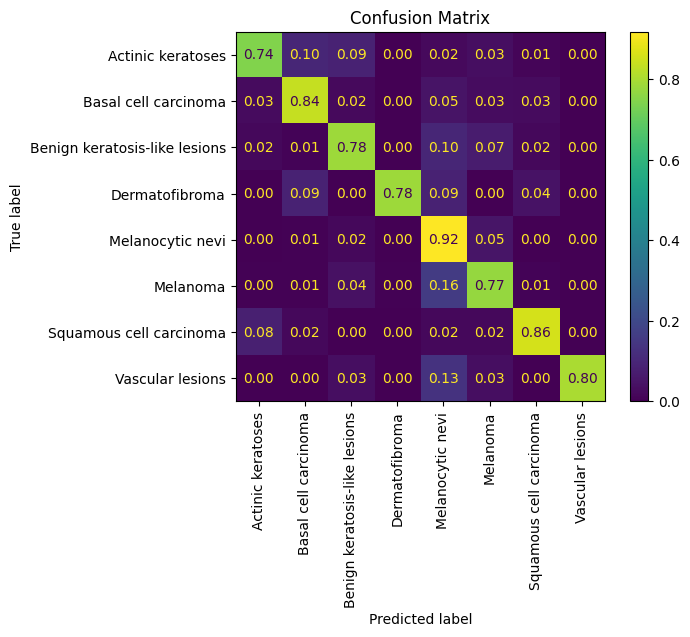

In [32]:
TEST_CM = TEST_CM.apply(pd.to_numeric)

cm_norm = TEST_CM.div(TEST_CM.sum(axis=1), axis=0)

disp = ConfusionMatrixDisplay(
    display_labels=cm_norm.index,
    confusion_matrix=cm_norm.values
)


disp.plot(values_format=".2f")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.show()


### Deriving per class metrics

In [33]:
metrics = {}

for className in TEST_CM.index:
    TP, FN, FP, TN = h.PredictionsPerClass(TEST_CM, className)
    accuracy, precision, recall, f1 = h.ClassMetrics(TP, FN, FP, TN)
    metrics[className] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
metrics = pd.DataFrame(metrics).T
display(metrics)

,accuracy,precision,recall,f1
Actinic keratoses,0.026378,0.744444,0.761364,0.752809
Basal cell carcinoma,0.120866,0.838798,0.921922,0.878398
Benign keratosis-like lesions,0.080315,0.784615,0.775665,0.780115
Dermatofibroma,0.007087,0.782609,0.720000,0.750000
Melanocytic nevi,0.457480,0.917852,0.902174,0.909945
Melanoma,0.138976,0.774123,0.779249,0.776678
Squamous cell carcinoma,0.016535,0.857143,0.656250,0.743363
Vascular lesions,0.009449,0.800000,0.923077,0.857143


### Inspecting with captum

Examining what features are relevant

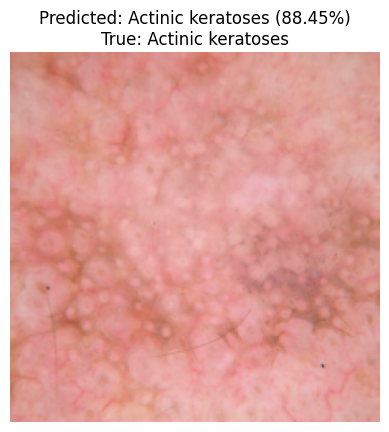

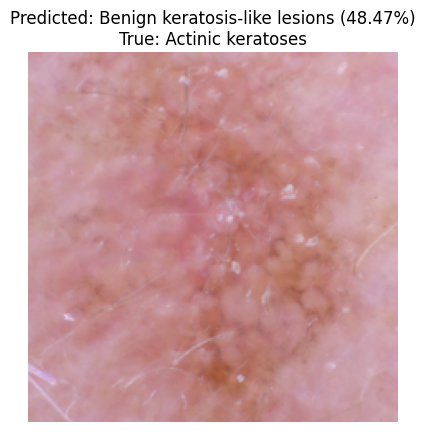

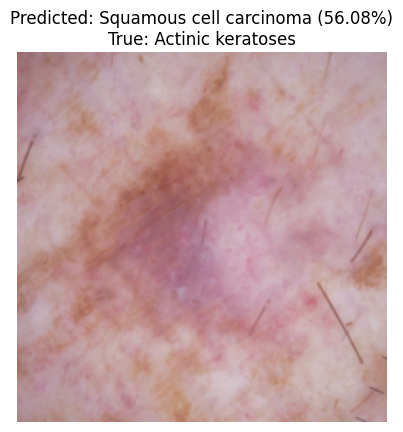

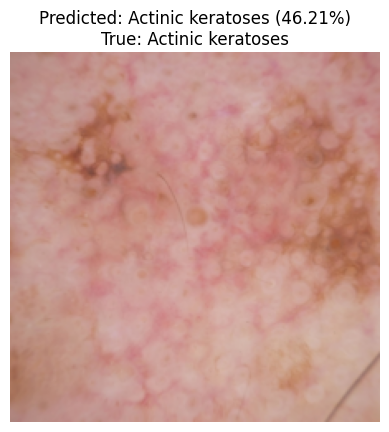

In [19]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)


for idx in range(len(preds)):
    img = images[idx].cpu()
    true_label = ClassNames[labels[idx].item()]
    pred_label = ClassNames[preds[idx].item()]
    confidence = probs[idx, preds[idx]].item()

    # If image was normalized, unnormalize it before plotting
    mean = torch.tensor(h.MEAN).view(3, 1, 1)
    std = torch.tensor(h.STD).view(3, 1, 1)

    img = img * std + mean
    img = img.clamp(0, 1)

    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
    f"Predicted: {pred_label} ({confidence:.2%})\n"
    f"True: {true_label}"
    )
    plt.show()

